In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [49]:
df_2024_1 = pd.read_csv('combust_2024.01.csv', sep=';', decimal=',')
df_2024_2 = pd.read_csv('combust_2024.02.csv', sep=';', decimal=',')
df_2025_1 = pd.read_csv('combust_2025.01.csv', sep=';', decimal=',')
df_2025_2 = pd.read_csv('combust_2025.02.csv', sep=';', decimal=',')


C:\Users\vitor.jsouza\AppData\Local\Temp\ipykernel_24588\1050854873.py:3: DtypeWarning: Columns (0: Regiao - Sigla, 1: Estado - Sigla, 2: Municipio, 3: Revenda, 4: CNPJ da Revenda, 5: Nome da Rua, 6: Numero Rua, 7: Complemento, 8: Bairro, 9: Cep, 10: Produto, 11: Data da Coleta, 12: Unidade de Medida, 13: Bandeira) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025_1 = pd.read_csv('combust_2025.01.csv', sep=';', decimal=',')


In [50]:
df = pd.concat([df_2024_1, df_2024_2,df_2025_1, df_2025_2],ignore_index=True)

display(df.head())

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA


In [51]:
df.columns

Index(['Regiao - Sigla', 'Estado - Sigla', 'Municipio', 'Revenda',
       'CNPJ da Revenda', 'Nome da Rua', 'Numero Rua', 'Complemento', 'Bairro',
       'Cep', 'Produto', 'Data da Coleta', 'Valor de Venda', 'Valor de Compra',
       'Unidade de Medida', 'Bandeira'],
      dtype='str')

### 02 - Gasolina comum RJ

In [52]:
df_gas_com = df.loc[df['Produto'] == 'GASOLINA']

In [53]:
df_gas_com_rj = df.loc[(df['Estado - Sigla'] == 'RJ') & (df['Produto'] == 'GASOLINA')]
df_gas_com_rj.head()

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
122,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO DE COMBUSTIVEIS CONTORNO DE CAMPOS LTDA,31.212.889/0002-85,AVENIDA NILO PECANHA,614,/822 PATIO,PQ SANTO AMARO,28030-035,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,VIBRA
130,SE,RJ,CAMPOS DOS GOYTACAZES,ARARA FLUMINENSE COMERCIO DE COMBUSTIVEIS LTDA.,07.614.346/0004-71,AVENIDA ALBERTO TORRES,100,NaN,CENTRO,28010-117,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,RAIZEN
131,SE,RJ,CAMPOS DOS GOYTACAZES,POSTO SAO LUCAS DE CAMPOS LTDA,04.718.173/0001-09,"RODOVIA BR-101 KM 80,5",S/N,NaN,IBITIOCA,28120-000,GASOLINA,01/01/2024,5.89,NaN,R$ / litro,RAIZEN
133,SE,RJ,CAMPOS DOS GOYTACAZES,MOTO MERCANTIL CAMPISTA S A,28.935.153/0001-40,RUA DOS GOYTACAZES,342,NaN,CENTRO,28010-460,GASOLINA,01/01/2024,5.99,NaN,R$ / litro,VIBRA
136,SE,RJ,CAMPOS DOS GOYTACAZES,G.S. NOGUEIRA COMBUSTÍVEIS LTDA,03.784.646/0001-03,RUA JOAQUIM LORENA,6,NaN,URURAÍ,28020-230,GASOLINA,01/01/2024,5.79,NaN,R$ / litro,BRANCA


In [54]:
df_gas_com_rj['Data da Coleta'] = pd.to_datetime(df_gas_com_rj['Data da Coleta'], dayfirst= True)

In [55]:
df_gasosa_tempo = df_gas_com_rj.groupby('Data da Coleta')['Valor de Venda'].mean().reset_index().sort_values(by='Data da Coleta')
df_gasosa_tempo


,Data da Coleta,Valor de Venda
0,2024-01-01,5.674773
1,2024-01-02,5.638221
2,2024-01-03,5.769762
3,2024-01-04,5.632800
4,2024-01-05,5.396000
...,...,...
472,2025-12-25,6.790000
473,2025-12-26,6.277838
474,2025-12-29,6.095144
475,2025-12-30,6.148113


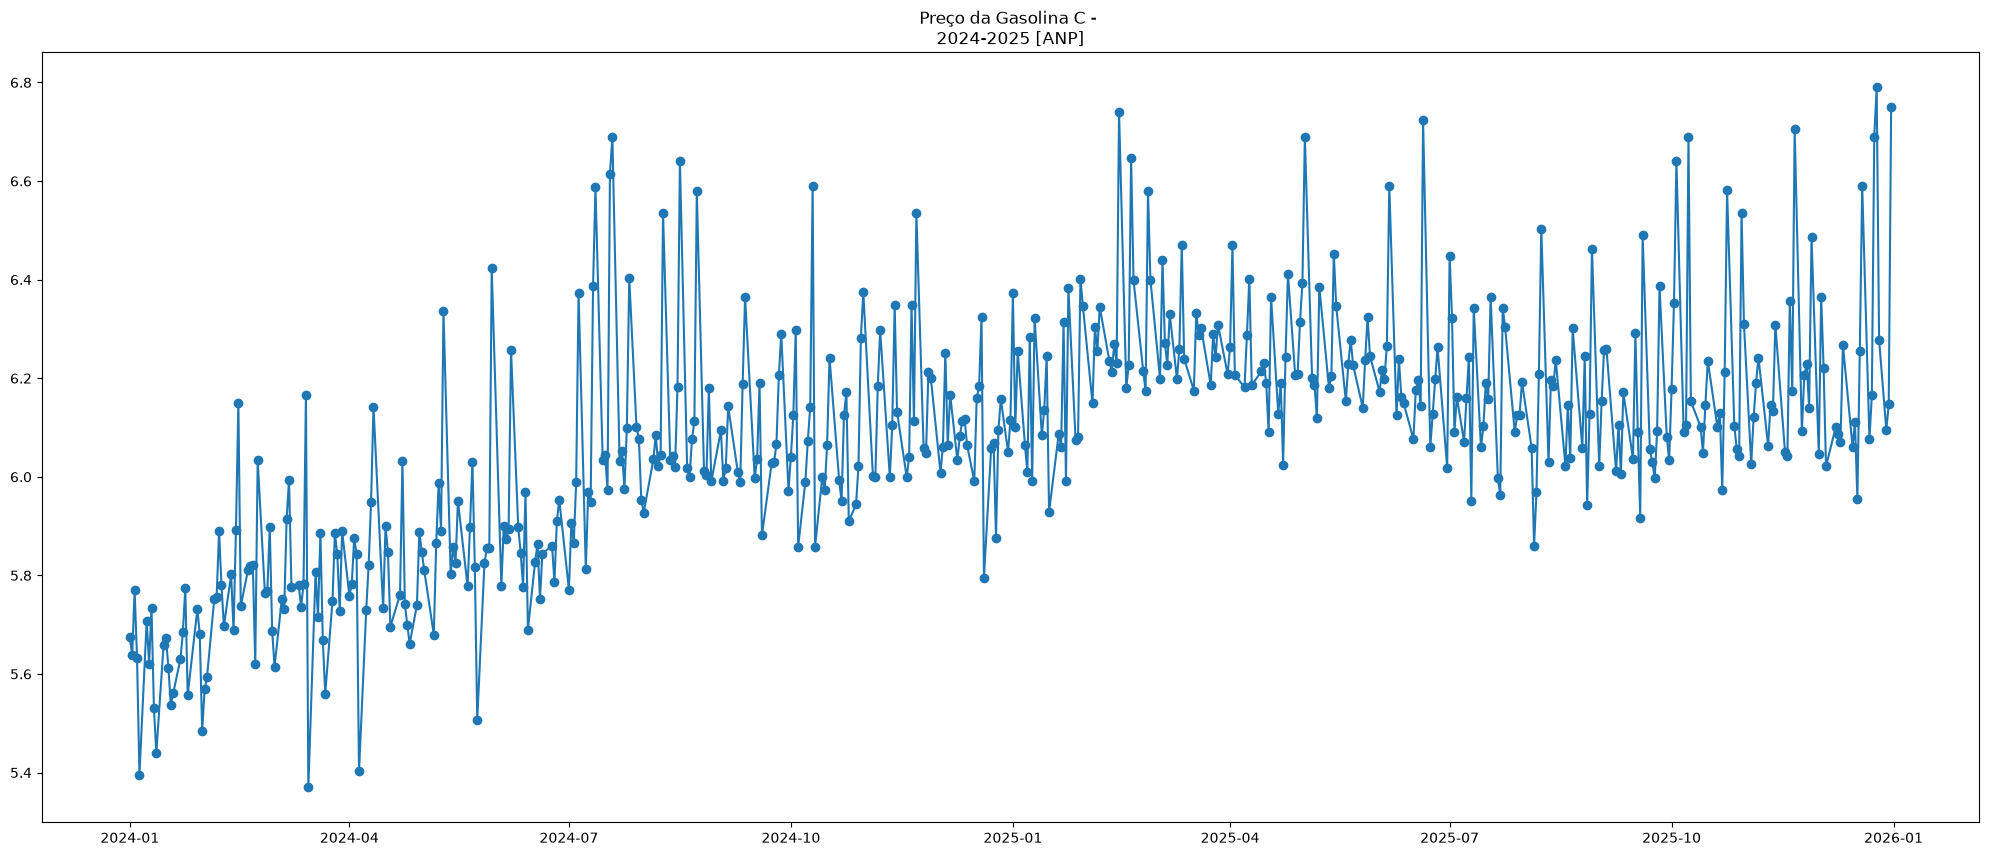

In [56]:
plt.figure(figsize=(25,10))
plt.plot(df_gasosa_tempo['Data da Coleta'], df_gasosa_tempo['Valor de Venda'], marker='o')
plt.title('Preço da Gasolina C - \n2024-2025 [ANP]')
plt.show()

In [57]:
df_munic_gas_rj = df_gas_com_rj.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by= 'Valor de Venda', ascending= False)
df_munic_gas_rj

,Municipio,Valor de Venda
29,TRES RIOS,6.591634
0,ANGRA DOS REIS,6.521620
18,PETROPOLIS,6.479639
2,BARRA DO PIRAI,6.375640
11,MACAE,6.364828
16,NOVA FRIBURGO,6.357044
10,ITAPERUNA,6.352013
6,CAMPOS DOS GOYTACAZES,6.338306
5,CABO FRIO,6.322089
23,SAO FRANCISCO DE ITABAPOANA,6.214804


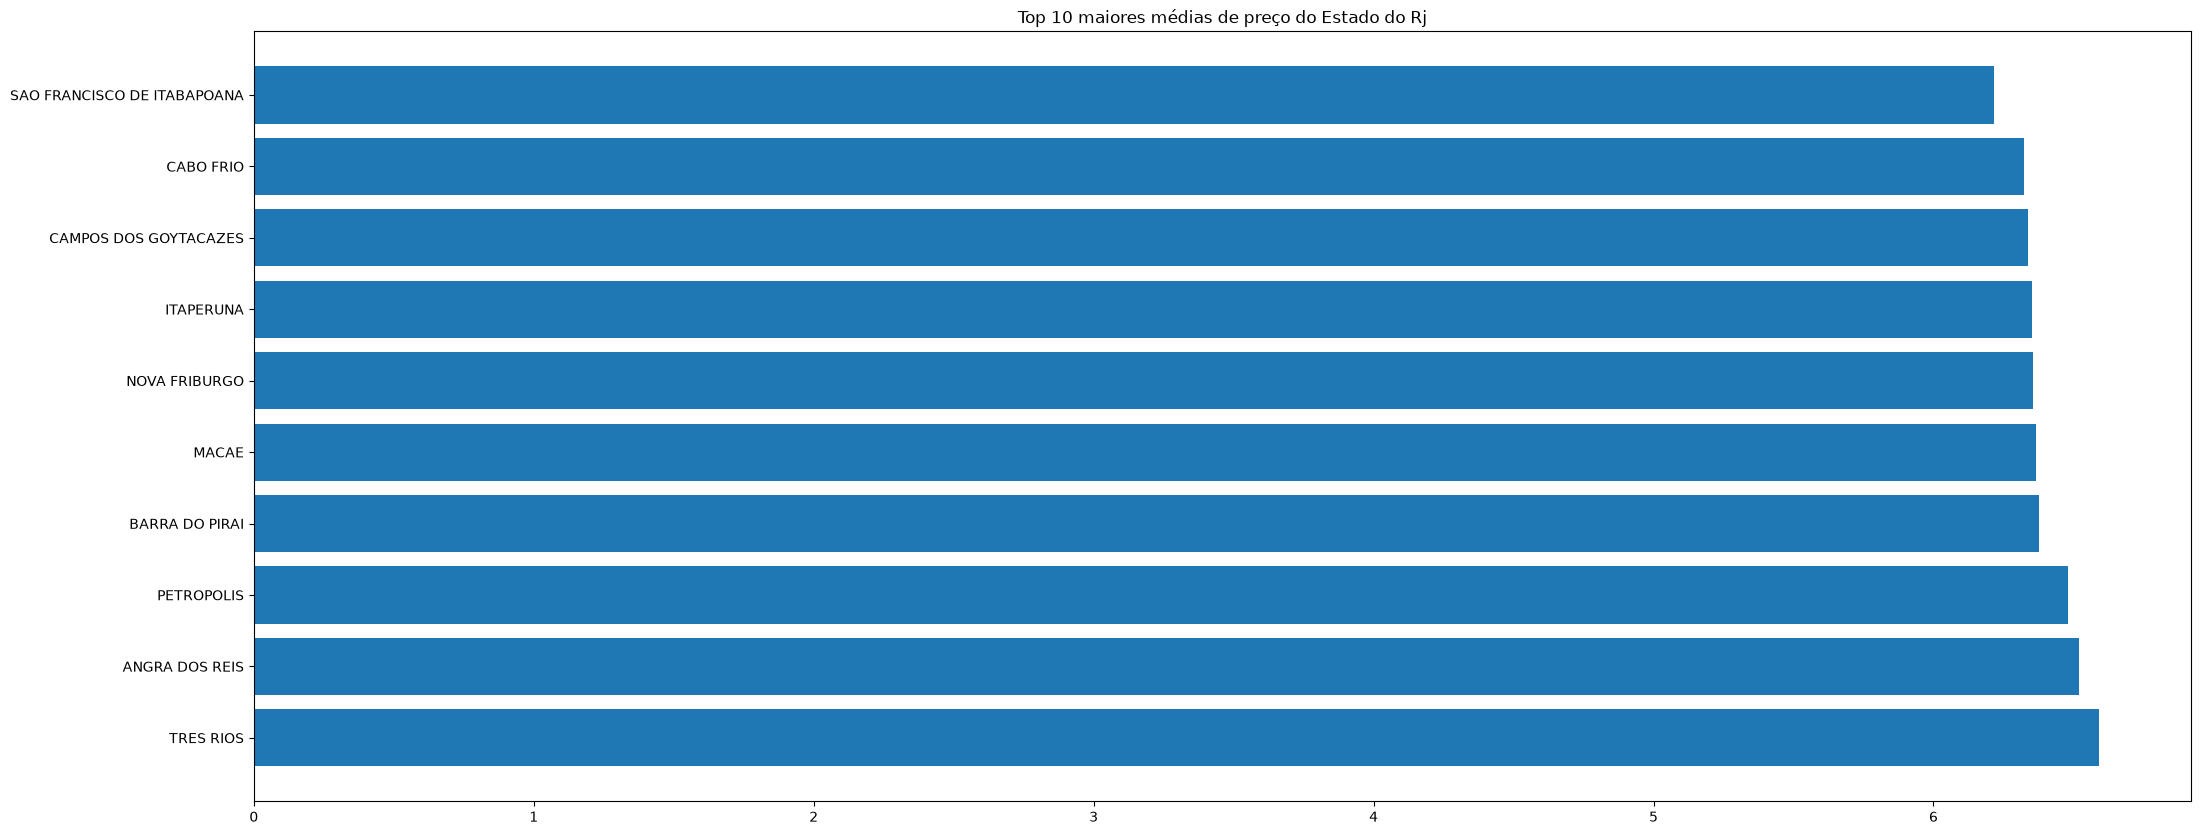

In [58]:
plt.figure(figsize=(25,10))
plt.barh(df_munic_gas_rj['Municipio'].head(10), df_munic_gas_rj['Valor de Venda'].head(10)) # .head visualiza de cima pra baixo
plt.title('Top 10 maiores médias de preço do Estado do Rj')
plt.show()

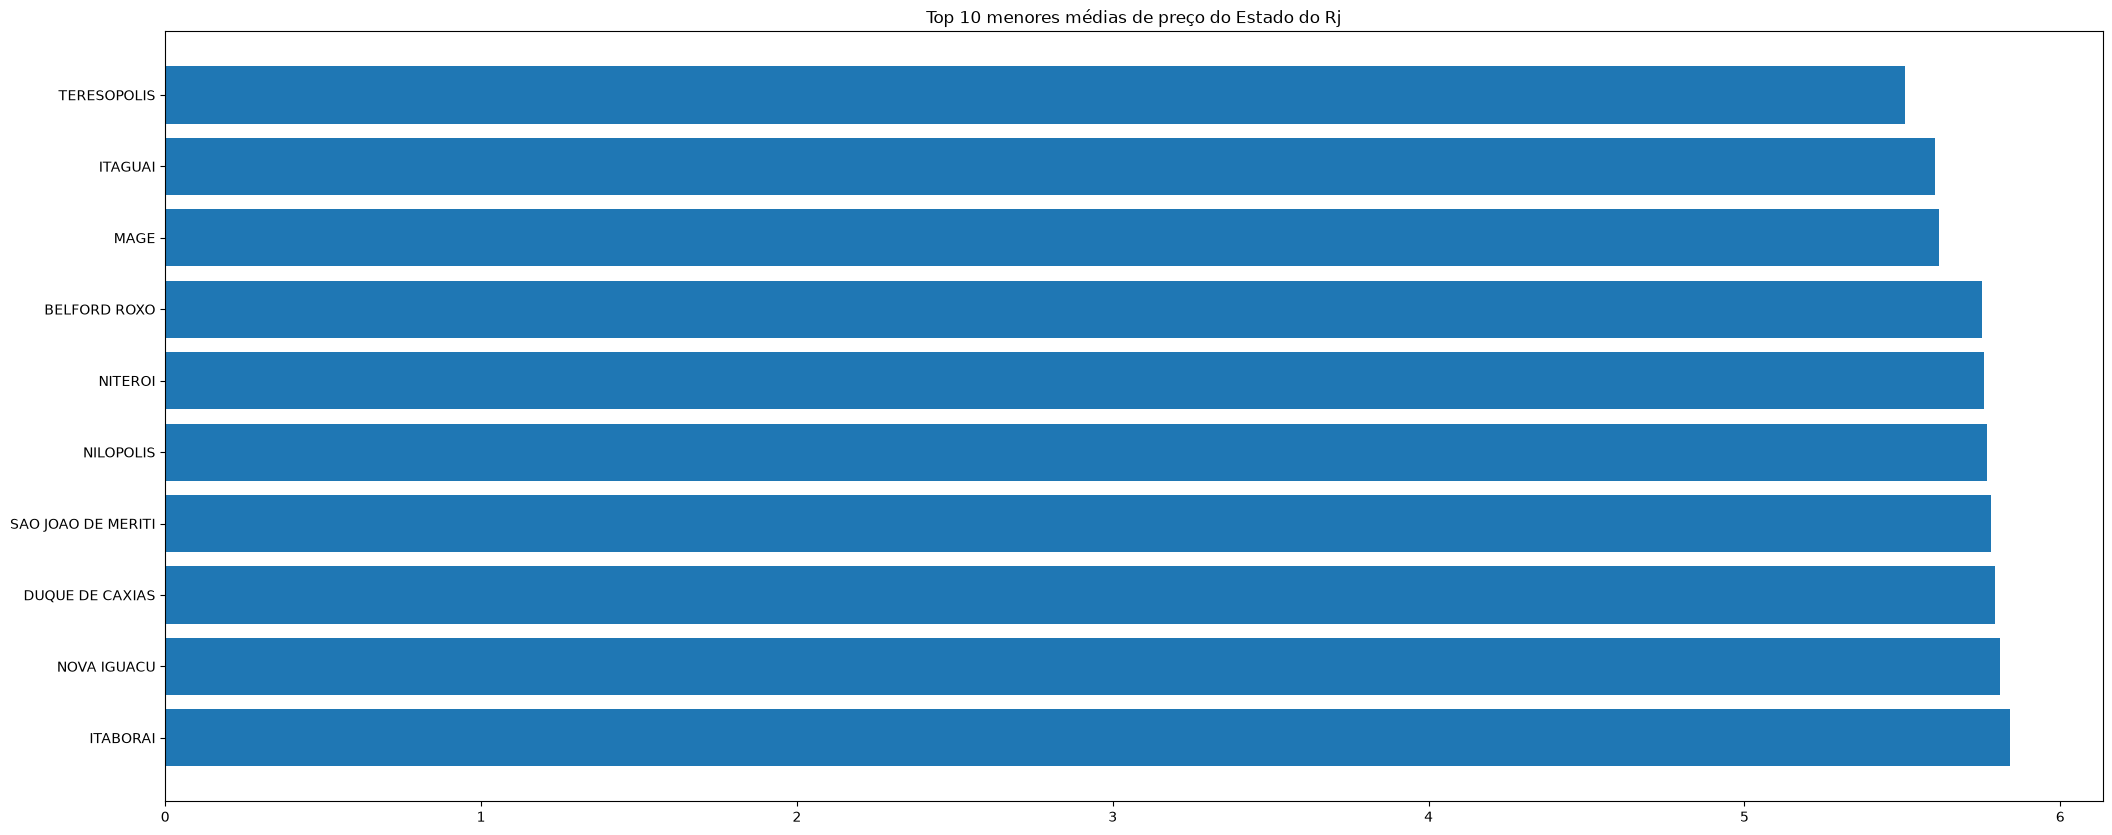

In [59]:
plt.figure(figsize=(25,10))
plt.barh(df_munic_gas_rj['Municipio'].tail(10), df_munic_gas_rj['Valor de Venda'].tail(10)) # .tail visualiza debaixo pra cima
plt.title('Top 10 menores médias de preço do Estado do Rj')
plt.show()

### 03 - Outliers de preço: Gasolina Comum no RJ

In [60]:
df_gas_com_post_rj = df_gas_com_rj.groupby('Revenda')['Valor de Venda'].mean().reset_index().sort_values(by= 'Valor de Venda', ascending= False)
df_gas_com_post_rj

,Revenda,Valor de Venda
690,POSTO JARDIM OCEANICO LTDA.,7.750674
76,AUTO POSTO DE COMBUSTIVEIS M C 2000 DE SANTA I...,7.415000
776,POSTO SATURNO FRIBURGO LTDA,6.824444
1,A C TRANCOZO M B COMBUSTIVEIS LTDA,6.742157
304,COMERCIO DE PETROLEO E DERIVADOS COND DO RIO N...,6.713529
...,...,...
668,POSTO FLAMAREDI EIRELI,5.282000
571,POSTO DE GASOLINA JARDIM SULACAP LTDA,5.226364
569,POSTO DE GASOLINA JAGUAR DO ANIL LTDA,5.156667
567,POSTO DE GASOLINA ITAJUBA LTDA,5.090000


In [61]:
array_gas_com_post_rj = np.array(df_gas_com_post_rj['Valor de Venda'])
media = np.mean(array_gas_com_post_rj)
mediana = np.median(array_gas_com_post_rj)
q1 = np.percentile(array_gas_com_post_rj, 25)
q2 = np.percentile(array_gas_com_post_rj, 50)  
q3 = np.percentile(array_gas_com_post_rj, 75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

print(f'Média {media}')
print(f'Mediana {mediana}')
print(f'Q1: {q1}')
print(f'Q2: {q2}')
print(f'Q3: {q3}')
print(f'Limite Superior {limite_superior}')
print(f'Limite Inferior {limite_inferior}')

Média 5.947818265606212
Mediana 5.9136419461502125
Q1: 5.692154135338346
Q2: 5.9136419461502125
Q3: 6.19
Limite Superior 6.936768796992482
Limite Inferior 4.945385338345865


In [62]:
outlier_sup_gas_com_rj = df_gas_com_post_rj.loc[df_gas_com_post_rj['Valor de Venda'] > limite_superior]
outlier_sup_gas_com_rj

,Revenda,Valor de Venda
690,POSTO JARDIM OCEANICO LTDA.,7.750674
76,AUTO POSTO DE COMBUSTIVEIS M C 2000 DE SANTA I...,7.415000


In [63]:
outlier_inf_gas_com_rj = df_gas_com_post_rj.loc[df_gas_com_post_rj['Valor de Venda'] < limite_inferior]
outlier_inf_gas_com_rj

,Revenda,Valor de Venda


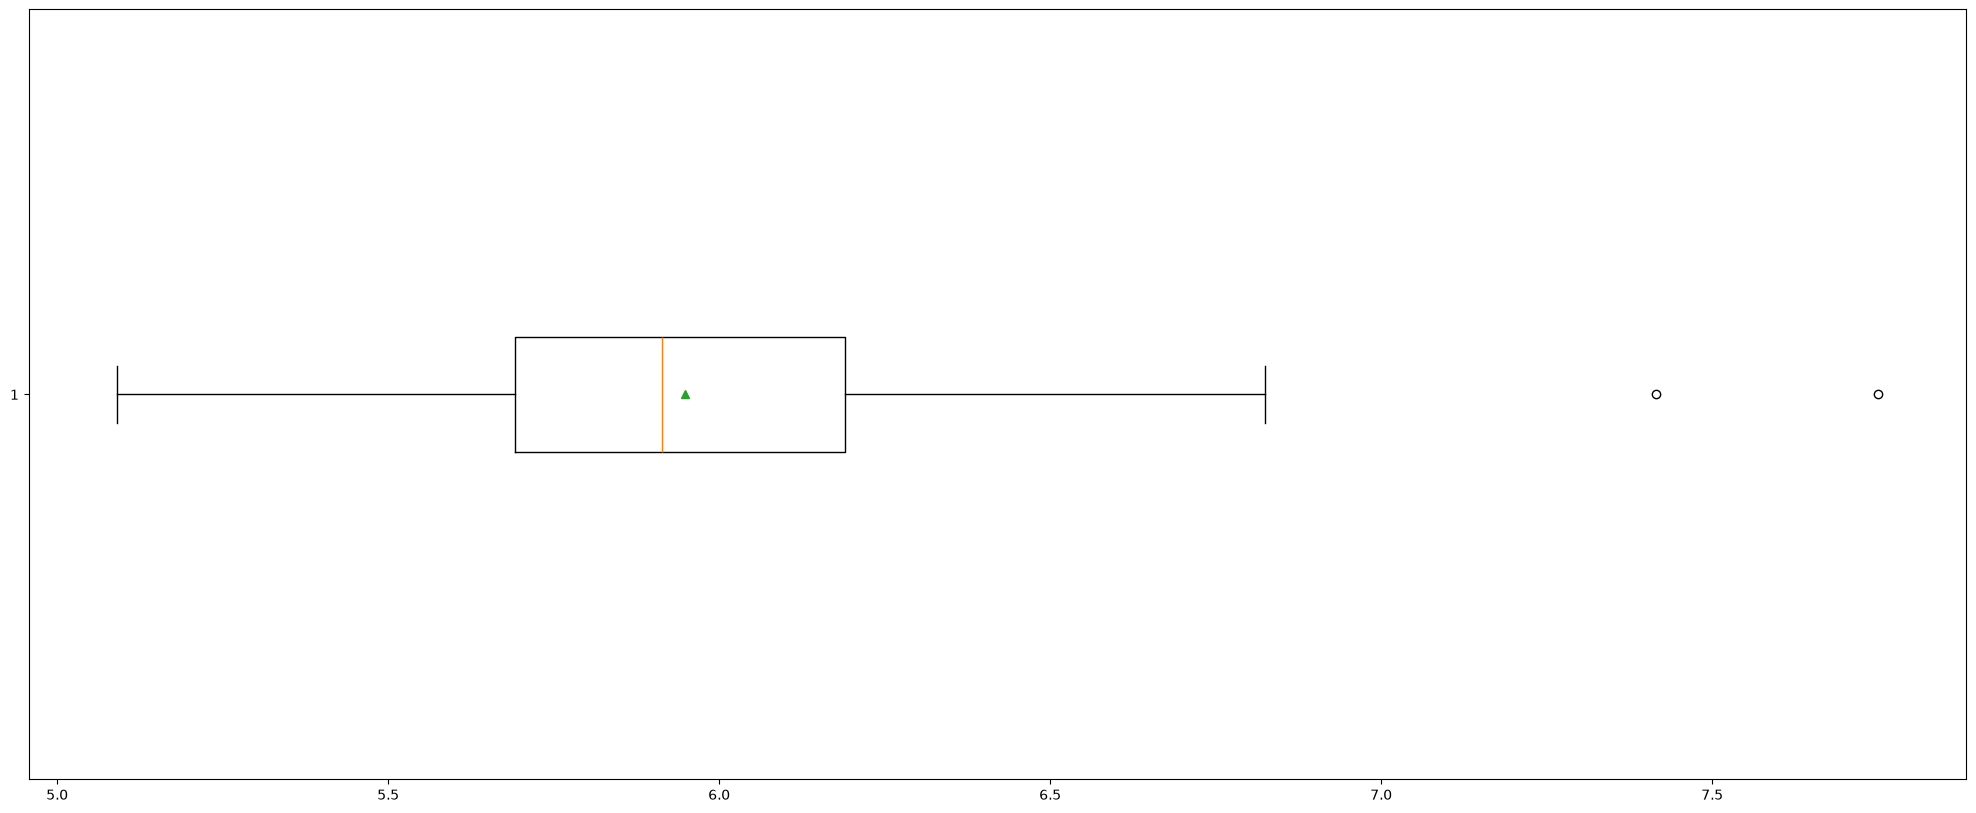

In [64]:
plt.figure(figsize=(25,10))
plt.boxplot(array_gas_com_post_rj, orientation='horizontal', showmeans= True) # showmeans é para mostrar a média
plt.show()

### 04 - Comparando estados: Etanol Hidratado

In [65]:
df_etanol = df.loc[df['Produto'] == 'ETANOL']
df_etanol_sp_rj = df_etanol.groupby('Estado - Sigla')['Valor de Venda'].mean().reset_index().sort_values(by= 'Valor de Venda', ascending= False)
df_etanol_sp_rj = df_etanol_sp_rj.loc[df_etanol_sp_rj['Estado - Sigla'].isin(['RJ', 'SP'])]
df_etanol_sp_rj

,Estado - Sigla,Valor de Venda
18,RJ,4.434487
25,SP,3.896279


In [66]:
df_etanol_rj = df_etanol.loc[df_etanol['Estado - Sigla'] == 'RJ']
df_munic_etanol_rj = df_etanol_rj.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by= 'Valor de Venda', ascending= False)
array_etanol_rj = np.array(df_munic_etanol_rj['Valor de Venda'])
q1 = np.percentile(array_etanol_rj, 25)
q2 = np.percentile(array_etanol_rj, 50)  
q3 = np.percentile(array_etanol_rj, 75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)


In [67]:
outilier_df_etanol_sup = df_munic_etanol_rj.loc[df_munic_etanol_rj['Valor de Venda'] > limite_superior]
outilier_df_etanol_sup

,Municipio,Valor de Venda
29,TRES RIOS,5.128235
18,PETROPOLIS,5.062155
0,ANGRA DOS REIS,5.005747


In [68]:
outilier_df_etanol_inf = df_munic_etanol_rj.loc[df_munic_etanol_rj ['Valor de Venda'] < limite_inferior]
outilier_df_etanol_inf

,Municipio,Valor de Venda
28,TERESOPOLIS,3.816982


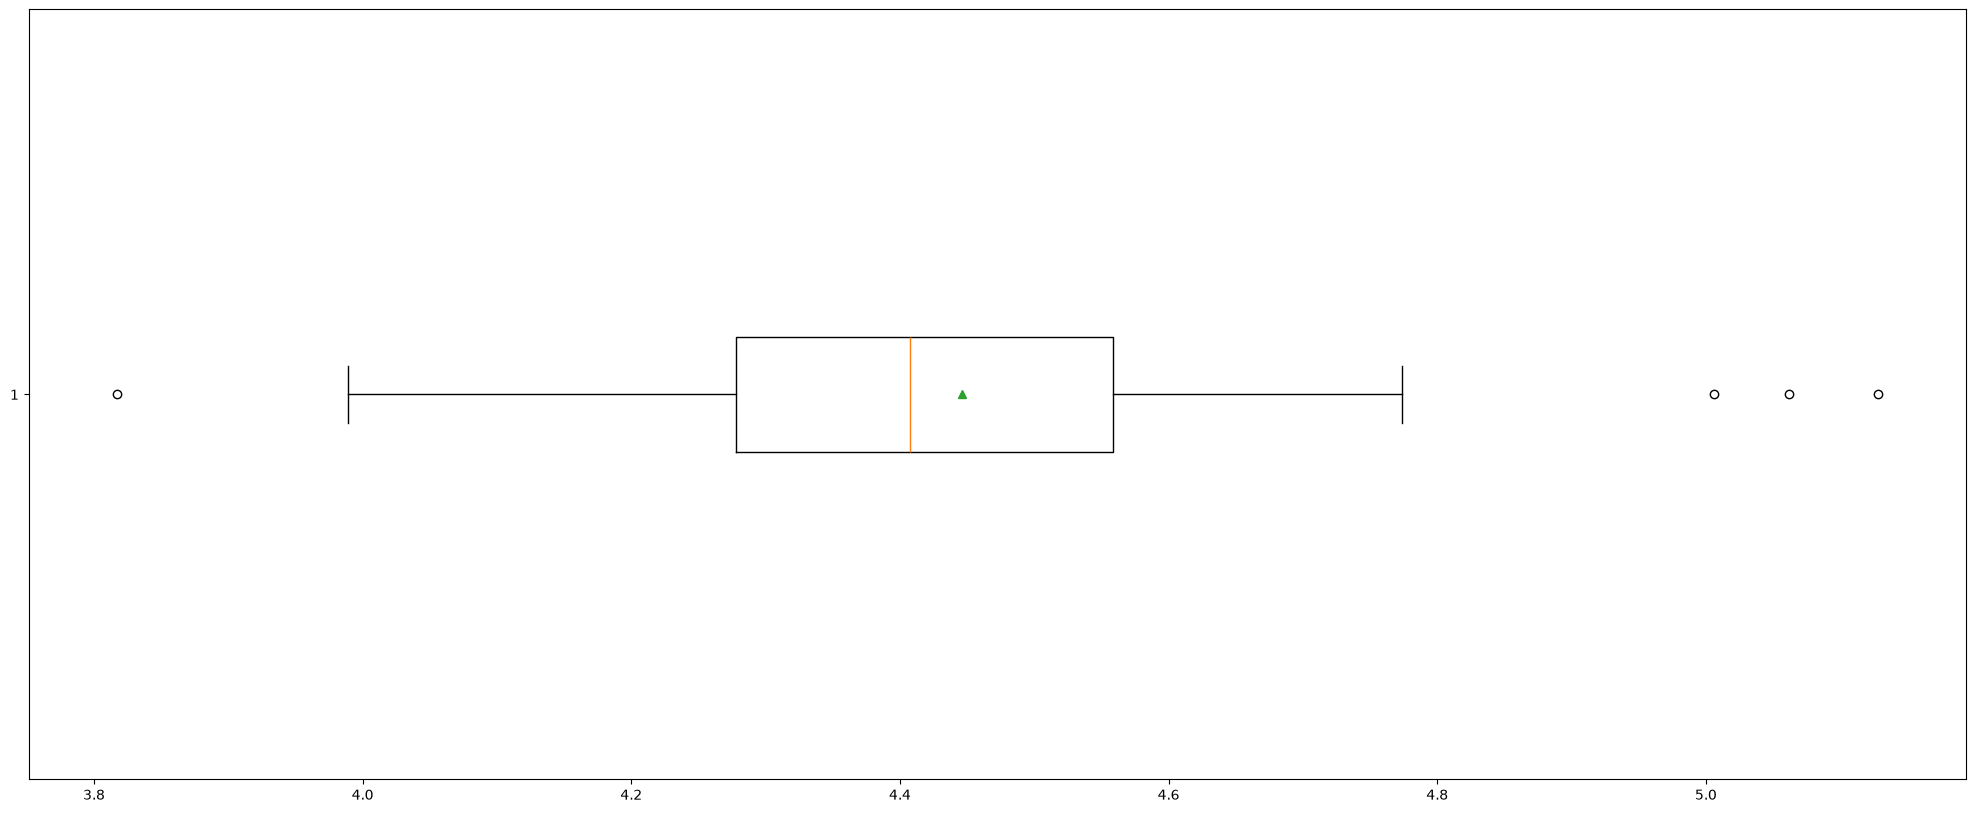

In [69]:
plt.figure(figsize=(25,10))
plt.boxplot(array_etanol_rj, orientation='horizontal', showmeans= True) # showmeans é para mostrar a média
plt.show()

In [70]:
df_etanol_sp = df_etanol.loc[df_etanol['Estado - Sigla'] == 'SP']
df_munic_etanol_sp = df_etanol_sp.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by= 'Valor de Venda', ascending= False)
array_etanol_sp = np.array(df_munic_etanol_sp['Valor de Venda'])
q1 = np.percentile(array_etanol_sp, 25)
q2 = np.percentile(array_etanol_sp, 50)  
q3 = np.percentile(array_etanol_sp, 75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

In [71]:
outilier_df_etanol_sup = df_munic_etanol_sp.loc[df_munic_etanol_sp['Valor de Venda'] > limite_superior]
outilier_df_etanol_sup

,Municipio,Valor de Venda
10,BARUERI,4.437937
24,CUBATAO,4.394575
31,GUARUJA,4.329950


In [72]:
outilier_df_etanol_inf = df_munic_etanol_sp.loc[df_munic_etanol_sp['Valor de Venda'] < limite_inferior]
outilier_df_etanol_inf

,Municipio,Valor de Venda
26,DRACENA,3.420116
92,SAO ROQUE,3.396087
81,SANTA BARBARA D'OESTE,3.373045
58,MIRASSOL,3.194895
76,PRESIDENTE VENCESLAU,3.182949


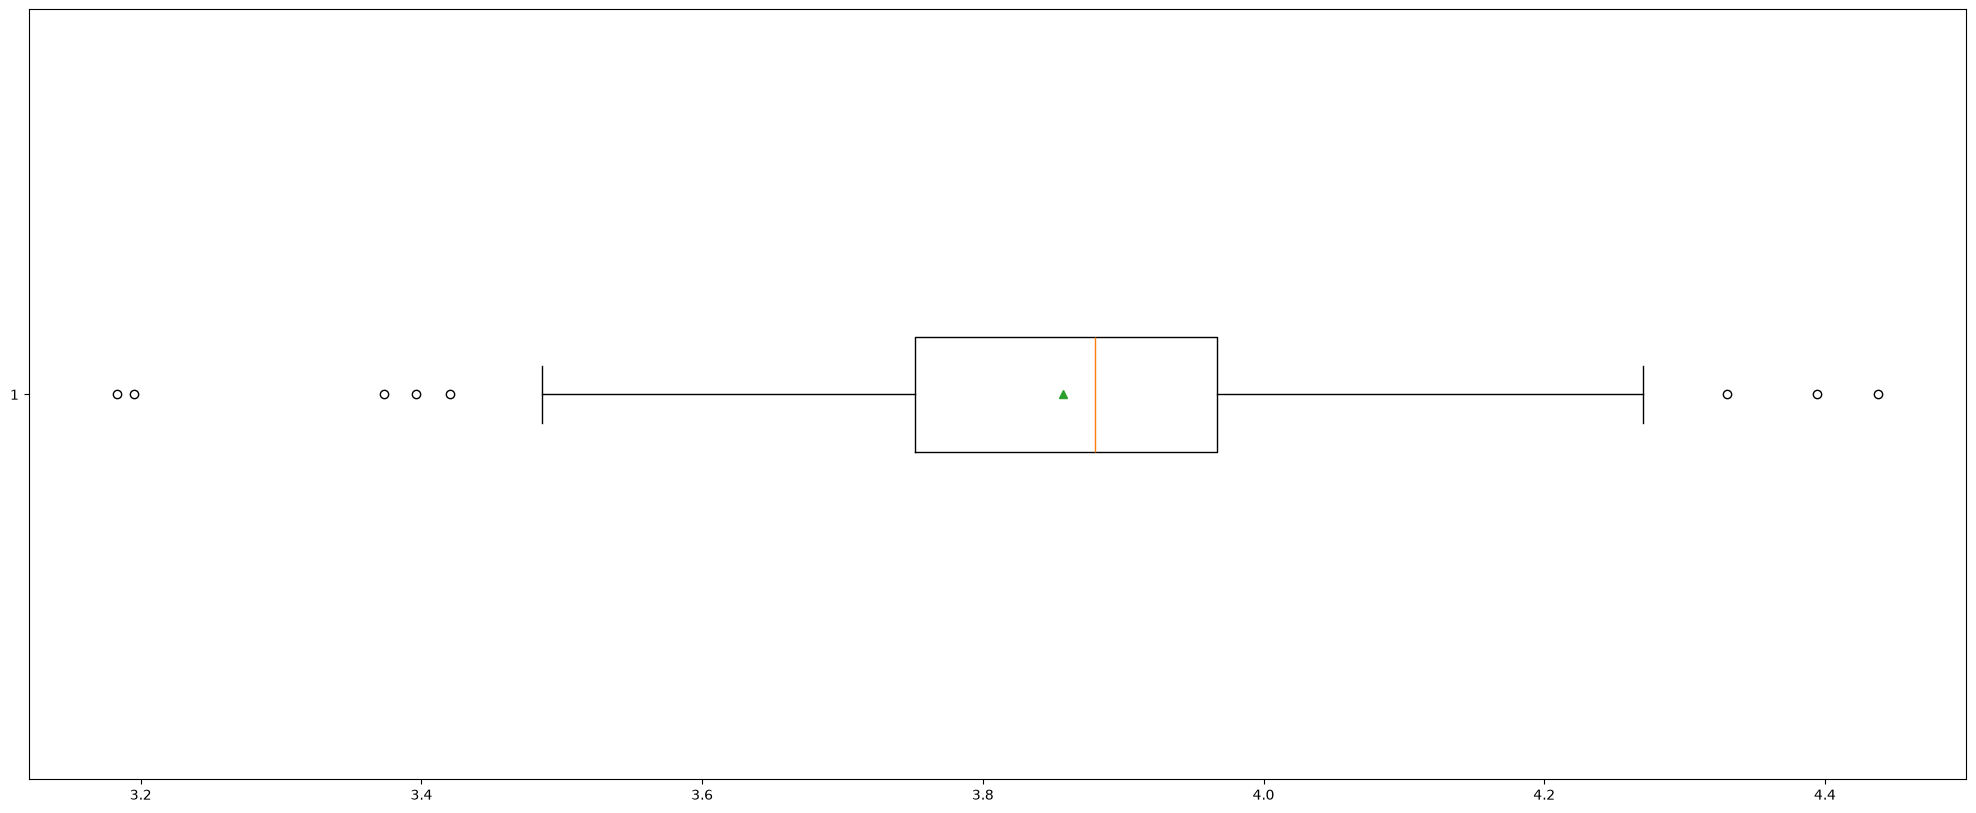

In [73]:
plt.figure(figsize=(25,10))
plt.boxplot(array_etanol_sp, orientation='horizontal', showmeans= True) # showmeans é para mostrar a média
plt.show()

### 5 - Bairros da capital: preços dentro ou fora do padrão? Parte 1

In [74]:
df_gas_com_rj = df.loc[(df['Municipio'] == 'RIO DE JANEIRO') & (df['Produto'] == 'GASOLINA')]
df_gas_com_rj.head()

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
2309,SE,RJ,RIO DE JANEIRO,POSTO DE COMBUSTIVEIS CANDIDO BENICIO LTDA,08.833.560/0001-39,RUA CANDIDO BENICIO,2742,NaN,PRACA SECA,22733-001,GASOLINA,02/01/2024,5.29,NaN,R$ / litro,VIBRA
2313,SE,RJ,RIO DE JANEIRO,POSTO E GARAGEM DOM HELDER CAMARA LTDA,04.802.584/0001-70,AVENIDA DOM HELDER CAMARA,4539,NaN,DEL CASTILHO,20771-000,GASOLINA,02/01/2024,5.69,NaN,R$ / litro,RAIZEN
2319,SE,RJ,RIO DE JANEIRO,POSTO DE GASOLINA ALTO ASTRAL DO MEIER LTDA,08.408.393/0001-89,RUA MEDINA,137,NaN,MEIER,20735-130,GASOLINA,02/01/2024,5.19,NaN,R$ / litro,BRANCA
2322,SE,RJ,RIO DE JANEIRO,POSTO DE GASOLINA JAGUAR DO ANIL LTDA,07.752.635/0001-94,AVENIDA TEN. CEL. MUNIZ DE ARAGAO,1240,NaN,ANIL,22765-008,GASOLINA,02/01/2024,5.09,NaN,R$ / litro,BRANCA
2328,SE,RJ,RIO DE JANEIRO,MARQUES'S PETER AUTO POSTO LTDA,05.570.770/0001-93,RUA JOSE DOMINGUES,250,NaN,ENCANTADO,20756-130,GASOLINA,02/01/2024,5.68,NaN,R$ / litro,VIBRA


In [75]:
df_bairro_gas_rj = df_gas_com_rj.groupby('Bairro')['Valor de Venda'].mean().reset_index().sort_values(by= 'Valor de Venda', ascending= False)
df_bairro_gas_rj

,Bairro,Valor de Venda
23,FLAMENGO,6.696667
41,JARDIM BOTANICO,6.614615
44,LAGOA,6.505385
55,PARQUE FLAMENGO,6.454706
21,ESTACIO,6.416882
...,...,...
50,MEIER,5.340000
37,JACARE,5.310000
49,MARIA DA GRACA,5.290000
43,JARDIM SULACAP,5.226364


### 5 - Bairros da capital: preços dentro ou fora do padrão? Parte 2

In [76]:
array_gas_com_bairro_rj = np.array(df_bairro_gas_rj['Valor de Venda'])

q1 = np.percentile(array_gas_com_bairro_rj, 25)
q3 = np.percentile(array_gas_com_bairro_rj, 75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'Limite Superior {limite_superior}')
print(f'Limite Inferior {limite_inferior}')

Q1: 5.640000000000001
Q3: 6.060588235294118
IQR: 0.42058823529411704
Limite Superior 6.691470588235293
Limite Inferior 5.009117647058825


### 5 - Bairros da capital: preços dentro ou fora do padrão? Parte 3

In [77]:
outilier_gas_com_bairro_rj_sup = df_bairro_gas_rj.loc[df_bairro_gas_rj['Valor de Venda'] > limite_superior]
outilier_gas_com_bairro_rj_sup

,Bairro,Valor de Venda
23,FLAMENGO,6.696667


In [78]:
outilier_gas_com_bairro_rj_inf = df_bairro_gas_rj.loc[df_bairro_gas_rj['Valor de Venda'] < limite_inferior]
outilier_gas_com_bairro_rj_inf

,Bairro,Valor de Venda


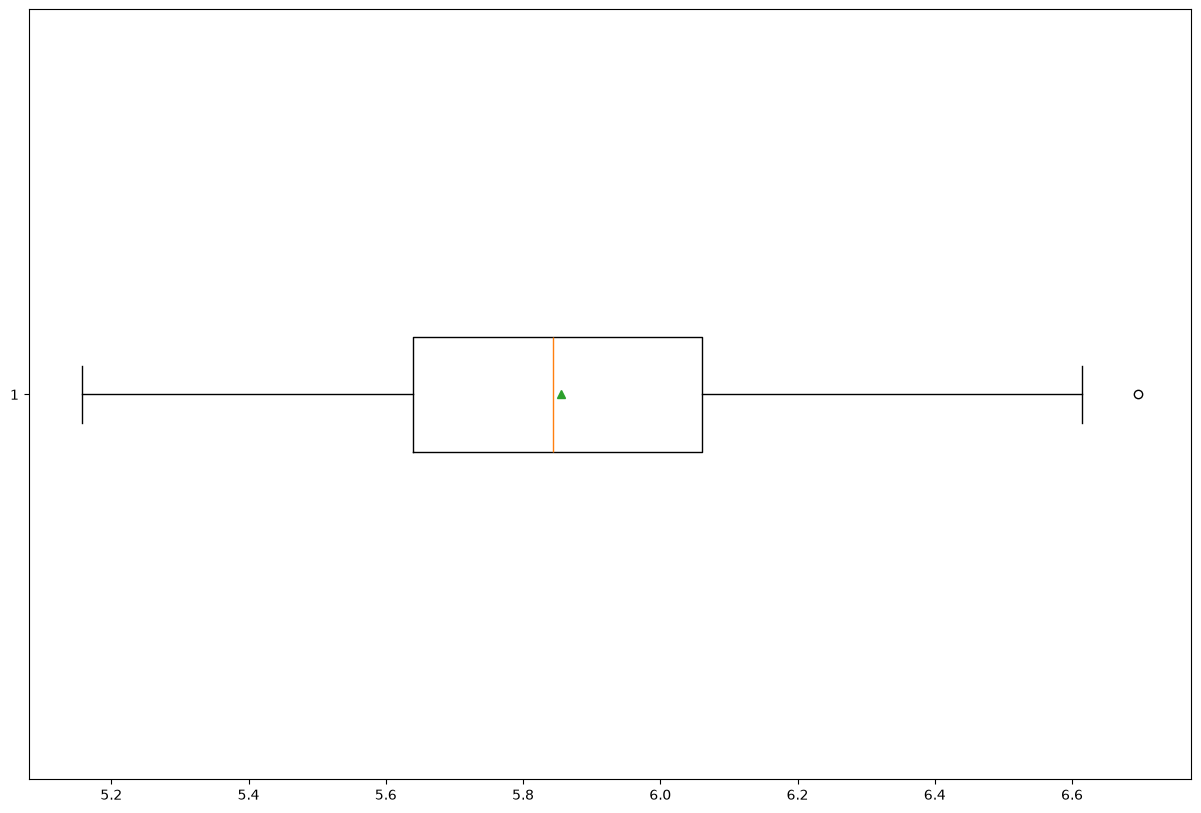

In [79]:
plt.figure(figsize=(15,10))
plt.boxplot(array_gas_com_bairro_rj, orientation='horizontal', showmeans= True) # showmeans é para mostrar a média
plt.show()